# PHASE 3 — ANALYSIS 3.3: Cross-Community Penetration & Cognitive Fusion

**Menjawab RQ3:** What socio-political dynamics emerge from the diffusion structure of protest discourse?

**Novelty claim:** Reconceptualizing 'distance' into 'Cross-Community Penetration' — hop distance as mathematical proof of cognitive fusion between communities that normally do not interact.

**Tiga Komponen:**
1. Community-to-Community Meta-Network (community-level interaction structure)
2. Echo Chamber Porosity — pre vs post shift (collapse of fragmentation)
3. Cognitive Fusion Index — integrated evidence

**Input files:**
- `Data_with_community2.csv`
- `network_nodes_with_community2.csv`
- `network_edges.csv`
- `penetration_by_narrative.csv`

## Cell 1: Import & Load

In [1]:
!pip install networkx python-louvain -q

import pandas as pd
import numpy as np
import networkx as nx
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Data_with_community2.csv')
df['date'] = pd.to_datetime(df['date'])
nodes = pd.read_csv('network_nodes_with_community2.csv')
pen = pd.read_csv('penetration_by_narrative.csv')

engagement_cols = ['retweet_count', 'reply_count', 'quote_count', 'favorite_count', 'view_count']
for col in engagement_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df['total_engagement'] = df[engagement_cols].sum(axis=1)

shift_date = pd.Timestamp('2025-08-27')
df['phase'] = df['date'].apply(lambda x: 'Pre-shift' if x < shift_date else 'Post-shift')

community_lookup = dict(zip(nodes['username'], nodes['community']))

print(f"Tweets: {len(df)}, Nodes: {len(nodes)}")
print(f"Communities: {nodes['community'].nunique()}")

Tweets: 14248, Nodes: 11426
Communities: 1667


## Cell 2: Rekonstruksi Temporal Edges with Community

In [2]:
edge_records = []

for _, row in df.iterrows():
    source = str(row.get('username_clean', row['username'])).lower().strip().replace('@', '')
    phase = row['phase']
    narrative = row['narrative']

    targets = []
    if pd.notna(row.get('in_reply_to_screen_name')):
        targets.append(str(row['in_reply_to_screen_name']).lower().strip().replace('@', ''))
    if pd.notna(row.get('quoted_username')):
        targets.append(str(row['quoted_username']).lower().strip().replace('@', ''))
    if pd.notna(row.get('mentions')):
        for m in str(row['mentions']).replace('@', '').split():
            if m.strip():
                targets.append(m.lower().strip())

    for target in targets:
        if source != target:
            s_comm = community_lookup.get(source)
            t_comm = community_lookup.get(target)
            if s_comm is not None and t_comm is not None:
                edge_records.append({
                    'source': source, 'target': target,
                    'source_community': int(s_comm),
                    'target_community': int(t_comm),
                    'is_cross': s_comm != t_comm,
                    'phase': phase,
                    'narrative': narrative
                })

df_edges = pd.DataFrame(edge_records)
print(f"Total edges with community info: {len(df_edges)}")
print(f"Cross-community: {df_edges['is_cross'].sum()} ({df_edges['is_cross'].mean()*100:.1f}%)")

Total edges with community info: 21414
Cross-community: 3258 (15.2%)


---
# KOMPONEN 1: COMMUNITY-TO-COMMUNITY META-NETWORK

Bangun graph di mana setiap node = komunitas, setiap edge = cross-community interaction.
Analisis struktur: apakah ada hub communities? Bridge communities?

## Cell 3: Build Community Meta-Network

In [3]:
# Only cross-community edges
cross_edges = df_edges[df_edges['is_cross']].copy()

# Aggregate: community-to-community edge weights
comm_edges = cross_edges.groupby(['source_community', 'target_community']).size().reset_index(name='weight')

# Build meta-network
G_meta = nx.Graph()
for _, row in comm_edges.iterrows():
    s, t, w = int(row['source_community']), int(row['target_community']), row['weight']
    if G_meta.has_edge(s, t):
        G_meta[s][t]['weight'] += w
    else:
        G_meta.add_edge(s, t, weight=w)

# Add community size as node attribute
comm_sizes = nodes.groupby('community').size().to_dict()
for node in G_meta.nodes():
    G_meta.nodes[node]['size'] = comm_sizes.get(node, 0)

print("=" * 70)
print("COMMUNITY META-NETWORK")
print("=" * 70)
print(f"Community-nodes: {G_meta.number_of_nodes()}")
print(f"Community-edges: {G_meta.number_of_edges()}")
print(f"Density: {nx.density(G_meta):.6f}")

# Connected components
components = list(nx.connected_components(G_meta))
largest_cc = max(components, key=len)
print(f"Connected components: {len(components)}")
print(f"Largest component: {len(largest_cc)} communities ({len(largest_cc)/G_meta.number_of_nodes()*100:.1f}%)")

# Degree stats
degrees = dict(G_meta.degree())
weighted_degrees = dict(G_meta.degree(weight='weight'))

print(f"\nDegree stats (meta-network):")
print(f"  Mean: {np.mean(list(degrees.values())):.1f}")
print(f"  Max: {max(degrees.values())}")
print(f"  Median: {np.median(list(degrees.values())):.1f}")

# Top hub communities
top_hubs = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:15]
print(f"\nTop 15 hub communities (most connections to other communities):")
for comm, deg in top_hubs:
    w_deg = weighted_degrees[comm]
    size = comm_sizes.get(comm, 0)
    print(f"  Community {comm}: degree={deg}, weighted={w_deg}, size={size} nodes")

COMMUNITY META-NETWORK
Community-nodes: 52
Community-edges: 328
Density: 0.247360
Connected components: 1
Largest component: 52 communities (100.0%)

Degree stats (meta-network):
  Mean: 12.6
  Max: 46
  Median: 13.0

Top 15 hub communities (most connections to other communities):
  Community 2: degree=46, weighted=1592, size=1075 nodes
  Community 9: degree=33, weighted=735, size=459 nodes
  Community 7: degree=31, weighted=276, size=581 nodes
  Community 12: degree=30, weighted=381, size=433 nodes
  Community 3: degree=30, weighted=489, size=333 nodes
  Community 11: degree=29, weighted=408, size=346 nodes
  Community 10: degree=27, weighted=251, size=332 nodes
  Community 1: degree=25, weighted=196, size=210 nodes
  Community 70: degree=23, weighted=239, size=187 nodes
  Community 43: degree=22, weighted=197, size=203 nodes
  Community 58: degree=22, weighted=88, size=177 nodes
  Community 42: degree=21, weighted=131, size=149 nodes
  Community 69: degree=21, weighted=194, size=170 

## Cell 4: Meta-Network — Betweenness Centrality (Bridge Communities)

In [4]:
# Betweenness centrality: which communities serve as bridges?
betweenness = nx.betweenness_centrality(G_meta, weight='weight')

print("=" * 70)
print("TOP 15 BRIDGE COMMUNITIES (highest betweenness centrality)")
print("=" * 70)

top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:15]
for comm, bc in top_bridges:
    deg = degrees[comm]
    size = comm_sizes.get(comm, 0)

    # What narratives are present in this community?
    comm_tweets = df[df['community'] == comm]
    narr_dist = comm_tweets['narrative'].value_counts().head(3).to_dict()

    print(f"\nCommunity {comm}: betweenness={bc:.4f}, degree={deg}, size={size}")
    print(f"  Top narratives: {narr_dist}")

TOP 15 BRIDGE COMMUNITIES (highest betweenness centrality)

Community 2: betweenness=0.4022, degree=46, size=1075
  Top narratives: {'Politik & Tuntutan': 517, 'Gerakan/Hashtag': 458, 'Demo & DPR': 214}

Community 9: betweenness=0.1608, degree=33, size=459
  Top narratives: {'Gerakan/Hashtag': 246, 'Demo & DPR': 123, 'Ekonomi Rakyat': 84}

Community 137: betweenness=0.1347, degree=3, size=20
  Top narratives: {'Demo & DPR': 9, 'Kekerasan Aparat': 1, 'Ekonomi Rakyat': 1}

Community 7: betweenness=0.1318, degree=31, size=581
  Top narratives: {'Kekerasan Aparat': 241, 'Gerakan/Hashtag': 108, 'Demo & DPR': 101}

Community 240: betweenness=0.0991, degree=3, size=17
  Top narratives: {'Gerakan/Hashtag': 2, 'Demo & DPR': 2, 'Keamanan & Respons': 1}

Community 14: betweenness=0.0865, degree=8, size=87
  Top narratives: {'Demo & DPR': 31, 'Kekerasan Aparat': 25, 'Gerakan/Hashtag': 3}

Community 12: betweenness=0.0864, degree=30, size=433
  Top narratives: {'Kekerasan Aparat': 178, 'Demo & DPR'

## Cell 5: Meta-Network per Narrative

Welke narasi menciptakan koneksi antar-komunitas yang paling banyak?

In [5]:
print("=" * 70)
print("COMMUNITY META-NETWORK — PER NARRATIVE")
print("=" * 70)

narratives = df['narrative'].dropna().unique()

meta_stats = []
for narr in sorted(narratives):
    narr_cross = cross_edges[cross_edges['narrative'] == narr]
    if len(narr_cross) == 0:
        continue

    # Build per-narrative meta-network
    narr_comm_edges = narr_cross.groupby(['source_community', 'target_community']).size().reset_index(name='weight')
    G_narr = nx.Graph()
    for _, row in narr_comm_edges.iterrows():
        s, t, w = int(row['source_community']), int(row['target_community']), row['weight']
        if G_narr.has_edge(s, t):
            G_narr[s][t]['weight'] += w
        else:
            G_narr.add_edge(s, t, weight=w)

    n_comms = G_narr.number_of_nodes()
    n_bridges = G_narr.number_of_edges()
    density = nx.density(G_narr) if n_comms > 1 else 0

    # Connected components
    comps = list(nx.connected_components(G_narr))
    lcc = max(comps, key=len) if comps else set()

    # Avg path length in LCC
    avg_path = None
    diameter = None
    if len(lcc) > 2 and len(lcc) <= 500:
        G_lcc = G_narr.subgraph(lcc)
        try:
            avg_path = nx.average_shortest_path_length(G_lcc)
            diameter = nx.diameter(G_lcc)
        except:
            pass

    meta_stats.append({
        'narrative': narr,
        'communities_connected': n_comms,
        'community_bridges': n_bridges,
        'meta_density': round(density, 6),
        'components': len(comps),
        'lcc_size': len(lcc),
        'lcc_pct': round(len(lcc)/n_comms*100, 1) if n_comms > 0 else 0,
        'avg_path_lcc': round(avg_path, 2) if avg_path else None,
        'diameter_lcc': diameter
    })

df_meta = pd.DataFrame(meta_stats).sort_values('communities_connected', ascending=False)
print(df_meta.to_string(index=False))

COMMUNITY META-NETWORK — PER NARRATIVE
         narrative  communities_connected  community_bridges  meta_density  components  lcc_size  lcc_pct  avg_path_lcc  diameter_lcc
   Gerakan/Hashtag                     37                168      0.252252           1        37    100.0          1.82             3
Politik & Tuntutan                     34                 98      0.174688           1        34    100.0          1.87             3
        Demo & DPR                     33                 84      0.159091           1        33    100.0          2.26             5
  Kekerasan Aparat                     32                120      0.241935           1        32    100.0          1.92             4
    Ekonomi Rakyat                     30                 90      0.206897           1        30    100.0          1.99             4
   Affan Kurniawan                     26                 39      0.120000           1        26    100.0          2.79             6
Keamanan & Respons     

---
# KOMPONEN 2: ECHO CHAMBER POROSITY — PRE vs POST SHIFT

Apakah komunitas yang awalnya tertutup (pre-shift) menjadi terbuka (post-shift)?
Ukur 'porosity' = proporsi interaksi yang menembus batas komunitas.

## Cell 6: Community Porosity — Pre vs Post Shift

In [6]:
# Per community, per phase: hitung porosity
porosity_data = []

for comm in df_edges['source_community'].unique():
    for phase in ['Pre-shift', 'Post-shift']:
        comm_phase_edges = df_edges[
            (df_edges['source_community'] == comm) &
            (df_edges['phase'] == phase)
        ]
        total = len(comm_phase_edges)
        if total < 5:  # Min threshold for meaningful porosity
            continue

        cross_count = comm_phase_edges['is_cross'].sum()
        porosity = cross_count / total
        unique_targets = comm_phase_edges['target_community'].nunique()

        porosity_data.append({
            'community': comm,
            'phase': phase,
            'total_edges': total,
            'cross_edges': cross_count,
            'porosity': porosity,
            'unique_target_communities': unique_targets
        })

df_porosity = pd.DataFrame(porosity_data)

print("=" * 70)
print("COMMUNITY POROSITY: PRE vs POST SHIFT")
print("=" * 70)

for phase in ['Pre-shift', 'Post-shift']:
    subset = df_porosity[df_porosity['phase'] == phase]
    print(f"\n--- {phase} ---")
    print(f"Communities with enough data: {len(subset)}")
    print(f"Mean porosity: {subset['porosity'].mean():.3f}")
    print(f"Median porosity: {subset['porosity'].median():.3f}")
    print(f"Communities with porosity > 0: {(subset['porosity'] > 0).sum()} ({(subset['porosity'] > 0).mean()*100:.1f}%)")
    print(f"Communities with porosity > 0.2: {(subset['porosity'] > 0.2).sum()} ({(subset['porosity'] > 0.2).mean()*100:.1f}%)")

# Paired comparison: communities present in BOTH phases
pre = df_porosity[df_porosity['phase'] == 'Pre-shift'].set_index('community')
post = df_porosity[df_porosity['phase'] == 'Post-shift'].set_index('community')
both = pre.join(post, lsuffix='_pre', rsuffix='_post', how='inner')

print(f"\n{'=' * 70}")
print(f"PAIRED COMPARISON: Communities present in BOTH phases")
print(f"{'=' * 70}")
print(f"Communities in both phases: {len(both)}")
print(f"Mean porosity pre: {both['porosity_pre'].mean():.3f}")
print(f"Mean porosity post: {both['porosity_post'].mean():.3f}")
print(f"Change: {both['porosity_post'].mean() - both['porosity_pre'].mean():+.3f}")

# Wilcoxon signed-rank test (paired)
if len(both) >= 10:
    w_stat, w_p = stats.wilcoxon(both['porosity_pre'], both['porosity_post'])
    print(f"\nWilcoxon signed-rank test: W={w_stat:.0f}, p={w_p:.6f}")
    print(f"{'Significant' if w_p < 0.05 else 'Not significant'} at alpha=0.05")

# Direction of change
both['porosity_change'] = both['porosity_post'] - both['porosity_pre']
increased = (both['porosity_change'] > 0).sum()
decreased = (both['porosity_change'] < 0).sum()
same = (both['porosity_change'] == 0).sum()
print(f"\nPorosity increased: {increased} ({increased/len(both)*100:.1f}%)")
print(f"Porosity decreased: {decreased} ({decreased/len(both)*100:.1f}%)")
print(f"Porosity unchanged: {same} ({same/len(both)*100:.1f}%)")

COMMUNITY POROSITY: PRE vs POST SHIFT

--- Pre-shift ---
Communities with enough data: 113
Mean porosity: 0.052
Median porosity: 0.000
Communities with porosity > 0: 37 (32.7%)
Communities with porosity > 0.2: 13 (11.5%)

--- Post-shift ---
Communities with enough data: 81
Mean porosity: 0.096
Median porosity: 0.059
Communities with porosity > 0: 43 (53.1%)
Communities with porosity > 0.2: 15 (18.5%)

PAIRED COMPARISON: Communities present in BOTH phases
Communities in both phases: 38
Mean porosity pre: 0.141
Mean porosity post: 0.176
Change: +0.036

Wilcoxon signed-rank test: W=178, p=0.024836
Significant at alpha=0.05

Porosity increased: 23 (60.5%)
Porosity decreased: 12 (31.6%)
Porosity unchanged: 3 (7.9%)


## Cell 7: Porosity Visualization

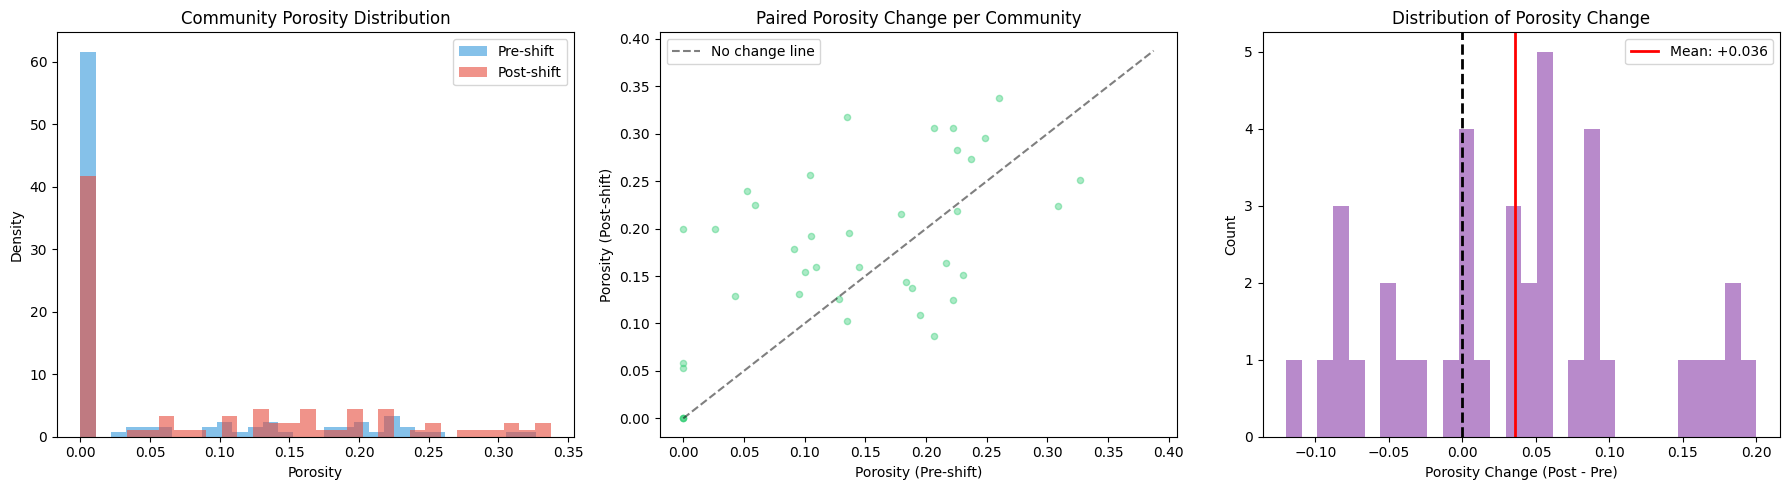

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribution of porosity pre vs post
pre_por = df_porosity[df_porosity['phase'] == 'Pre-shift']['porosity']
post_por = df_porosity[df_porosity['phase'] == 'Post-shift']['porosity']

axes[0].hist(pre_por, bins=30, alpha=0.6, color='#3498db', label='Pre-shift', density=True)
axes[0].hist(post_por, bins=30, alpha=0.6, color='#e74c3c', label='Post-shift', density=True)
axes[0].set_xlabel('Porosity')
axes[0].set_ylabel('Density')
axes[0].set_title('Community Porosity Distribution')
axes[0].legend()

# Plot 2: Paired change
if len(both) > 0:
    axes[1].scatter(both['porosity_pre'], both['porosity_post'], alpha=0.4, s=20, c='#2ecc71')
    lim_max = max(both['porosity_pre'].max(), both['porosity_post'].max()) + 0.05
    axes[1].plot([0, lim_max], [0, lim_max], 'k--', alpha=0.5, label='No change line')
    axes[1].set_xlabel('Porosity (Pre-shift)')
    axes[1].set_ylabel('Porosity (Post-shift)')
    axes[1].set_title('Paired Porosity Change per Community')
    axes[1].legend()

# Plot 3: Change distribution
if len(both) > 0:
    axes[2].hist(both['porosity_change'], bins=30, color='#9b59b6', alpha=0.7)
    axes[2].axvline(x=0, color='black', linestyle='--', linewidth=2)
    axes[2].axvline(x=both['porosity_change'].mean(), color='red', linestyle='-', linewidth=2, label=f"Mean: {both['porosity_change'].mean():+.3f}")
    axes[2].set_xlabel('Porosity Change (Post - Pre)')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Distribution of Porosity Change')
    axes[2].legend()

plt.tight_layout()
plt.show()

## Cell 8: Echo Chamber Porosity — Per Narrative

Narasi mana yang paling efektif menembus echo chambers?

In [8]:
print("=" * 70)
print("NARRATIVE POROSITY: Which narrative best breaks echo chambers?")
print("=" * 70)

narr_porosity = []
for narr in sorted(df_edges['narrative'].dropna().unique()):
    narr_edges = df_edges[df_edges['narrative'] == narr]
    total = len(narr_edges)
    cross_count = narr_edges['is_cross'].sum()

    if total < 10:
        continue

    # Unique community pairs connected
    cross_only = narr_edges[narr_edges['is_cross']]
    pairs = set()
    for _, row in cross_only.iterrows():
        pair = tuple(sorted([int(row['source_community']), int(row['target_community'])]))
        pairs.add(pair)

    narr_porosity.append({
        'narrative': narr,
        'total_edges': total,
        'cross_edges': cross_count,
        'porosity': round(cross_count / total, 3),
        'unique_community_pairs': len(pairs),
        'source_communities': narr_edges['source_community'].nunique(),
        'target_communities': narr_edges['target_community'].nunique()
    })

df_narr_por = pd.DataFrame(narr_porosity).sort_values('porosity', ascending=False)
print(df_narr_por.to_string(index=False))

NARRATIVE POROSITY: Which narrative best breaks echo chambers?
         narrative  total_edges  cross_edges  porosity  unique_community_pairs  source_communities  target_communities
   Gerakan/Hashtag         4694          985     0.210                     168                 222                 223
Keamanan & Respons          205           42     0.205                      25                  48                  49
Politik & Tuntutan         2443          502     0.205                      98                 102                 102
    Ekonomi Rakyat         1671          216     0.129                      90                 132                 132
   Affan Kurniawan          594           70     0.118                      39                  78                  76
  Kekerasan Aparat         3064          324     0.106                     120                 496                 498
        Demo & DPR         3126          168     0.054                      84                 629      

---
# KOMPONEN 3: COGNITIVE FUSION INDEX

Composite metric yang mengukur seberapa kuat 'cognitive fusion' terjadi per narasi.
Menggabungkan: hop depth, cross-community ratio, community reach, engagement velocity.

## Cell 9: Cognitive Fusion Index

COGNITIVE FUSION — RAW METRICS
         narrative  max_hop  avg_hop  cross_ratio  communities_reached  reach_pct  porosity  unique_community_pairs
        Demo & DPR        5     2.27          6.4                  683       41.0     0.054                      84
  Kekerasan Aparat        4     1.93         10.9                  540       32.4     0.106                     120
   Gerakan/Hashtag        3     1.83         20.5                  253       15.2     0.210                     168
    Ekonomi Rakyat        4     2.00         14.5                  154        9.2     0.129                      90
Politik & Tuntutan        3     1.87         24.7                  122        7.3     0.205                      98
   Affan Kurniawan        7     2.84         13.7                  102        6.1     0.118                      39
Keamanan & Respons        5     2.63         18.4                   68        4.1     0.205                      25

COGNITIVE FUSION INDEX — COMPOSITE RANKI

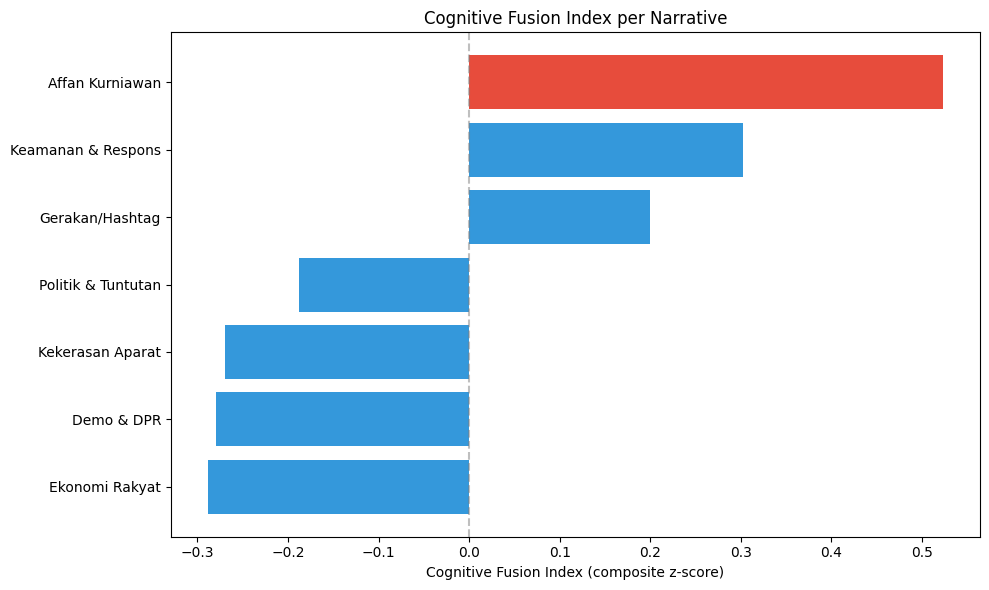

In [9]:
from scipy.stats import zscore

# Merge penetration data with porosity data
fusion_data = pen[['narrative', 'max_hop', 'avg_hop', 'cross_ratio', 'communities_reached', 'reach_pct']].copy()
fusion_data = fusion_data.merge(df_narr_por[['narrative', 'porosity', 'unique_community_pairs']], on='narrative', how='left')

print("=" * 70)
print("COGNITIVE FUSION — RAW METRICS")
print("=" * 70)
print(fusion_data.to_string(index=False))

# Z-score normalization for composite index
fusion_metrics = ['max_hop', 'avg_hop', 'porosity', 'unique_community_pairs']
fusion_calc = fusion_data[['narrative'] + fusion_metrics].dropna().copy()

for col in fusion_metrics:
    fusion_calc[f'{col}_z'] = zscore(fusion_calc[col])

z_cols = [f'{col}_z' for col in fusion_metrics]
fusion_calc['cognitive_fusion_index'] = fusion_calc[z_cols].mean(axis=1)
fusion_calc = fusion_calc.sort_values('cognitive_fusion_index', ascending=False)
fusion_calc['rank'] = range(1, len(fusion_calc) + 1)

print(f"\n{'=' * 70}")
print("COGNITIVE FUSION INDEX — COMPOSITE RANKING")
print("=" * 70)
print(fusion_calc[['rank', 'narrative'] + fusion_metrics + ['cognitive_fusion_index']].to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#e74c3c' if 'Affan' in n else '#3498db' for n in fusion_calc['narrative']]
ax.barh(range(len(fusion_calc)), fusion_calc['cognitive_fusion_index'], color=colors_bar)
ax.set_yticks(range(len(fusion_calc)))
ax.set_yticklabels(fusion_calc['narrative'])
ax.set_xlabel('Cognitive Fusion Index (composite z-score)')
ax.set_title('Cognitive Fusion Index per Narrative')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cell 10: Wide-but-Shallow vs Narrow-but-Deep — Final Evidence

In [10]:
print("=" * 80)
print("FINAL EVIDENCE: TWO MODES OF DIFFUSION")
print("=" * 80)

key_narratives = ['Demo & DPR', 'Affan Kurniawan', 'Kekerasan Aparat']

for narr in key_narratives:
    pen_row = pen[pen['narrative'] == narr]
    por_row = df_narr_por[df_narr_por['narrative'] == narr]
    fusion_row = fusion_calc[fusion_calc['narrative'] == narr]

    if len(pen_row) == 0:
        continue

    p = pen_row.iloc[0]

    print(f"\n--- {narr} ---")
    print(f"BREADTH: {int(p['communities_reached'])} communities ({p['reach_pct']:.1f}%), {int(p['total_tweets'])} tweets")
    print(f"DEPTH:   max hop={int(p['max_hop'])}, avg hop={p['avg_hop']:.2f}")
    print(f"CROSS:   cross-ratio={p['cross_ratio']:.1f}%")
    if len(por_row) > 0:
        print(f"POROSITY: {por_row.iloc[0]['porosity']:.3f}, unique community pairs={int(por_row.iloc[0]['unique_community_pairs'])}")
    if len(fusion_row) > 0:
        print(f"FUSION INDEX: {fusion_row.iloc[0]['cognitive_fusion_index']:.3f} (rank #{int(fusion_row.iloc[0]['rank'])})")

    # Mode classification
    if p['communities_reached'] > 300 and p['max_hop'] <= 5:
        mode = 'WIDE-BUT-SHALLOW'
    elif p['max_hop'] >= 6:
        mode = 'NARROW-BUT-DEEP'
    else:
        mode = 'MIXED'
    print(f"MODE: {mode}")

print(f"\n{'=' * 80}")
print("INTERPRETATION")
print("=" * 80)
print("Demo & DPR: Wide reach but shallow penetration — largely trapped in echo chambers.")
print("Affan Kurniawan: Narrow reach but deepest penetration — cognitive fusion across")
print("  communities that normally don't interact. Personal narrative of state violence")
print("  victim breaks through structural barriers that economic grievance cannot.")
print("This dual mode is the core evidence for 'Solidarity vs Algorithms' thesis.")

FINAL EVIDENCE: TWO MODES OF DIFFUSION

--- Demo & DPR ---
BREADTH: 683 communities (41.0%), 2482 tweets
DEPTH:   max hop=5, avg hop=2.27
CROSS:   cross-ratio=6.4%
POROSITY: 0.054, unique community pairs=84
FUSION INDEX: -0.280 (rank #6)
MODE: WIDE-BUT-SHALLOW

--- Affan Kurniawan ---
BREADTH: 102 communities (6.1%), 743 tweets
DEPTH:   max hop=7, avg hop=2.84
CROSS:   cross-ratio=13.7%
POROSITY: 0.118, unique community pairs=39
FUSION INDEX: 0.524 (rank #1)
MODE: NARROW-BUT-DEEP

--- Kekerasan Aparat ---
BREADTH: 540 communities (32.4%), 2276 tweets
DEPTH:   max hop=4, avg hop=1.93
CROSS:   cross-ratio=10.9%
POROSITY: 0.106, unique community pairs=120
FUSION INDEX: -0.270 (rank #5)
MODE: WIDE-BUT-SHALLOW

INTERPRETATION
Demo & DPR: Wide reach but shallow penetration — largely trapped in echo chambers.
Affan Kurniawan: Narrow reach but deepest penetration — cognitive fusion across
  communities that normally don't interact. Personal narrative of state violence
  victim breaks through s

## Cell 11: Narrative Overlap Between Communities — Shared Topics as Fusion Evidence

In [11]:
# For each community: what narratives are discussed?
comm_narratives = df.groupby('community')['narrative'].apply(lambda x: set(x.dropna())).to_dict()

# Narrative diversity per community
narr_counts = {comm: len(narrs) for comm, narrs in comm_narratives.items()}

print("=" * 70)
print("NARRATIVE DIVERSITY PER COMMUNITY")
print("=" * 70)

narr_count_series = pd.Series(narr_counts)
print(f"Communities: {len(narr_count_series)}")
print(f"Mean narratives per community: {narr_count_series.mean():.2f}")
print(f"Median: {narr_count_series.median():.1f}")
print(f"\nDistribution:")
print(narr_count_series.value_counts().sort_index())

# Communities that discuss BOTH Demo & DPR AND Affan Kurniawan
both_narr = [comm for comm, narrs in comm_narratives.items()
             if 'Demo & DPR' in narrs and 'Affan Kurniawan' in narrs]
demo_only = [comm for comm, narrs in comm_narratives.items()
             if 'Demo & DPR' in narrs and 'Affan Kurniawan' not in narrs]
affan_only = [comm for comm, narrs in comm_narratives.items()
              if 'Affan Kurniawan' in narrs and 'Demo & DPR' not in narrs]

print(f"\n{'=' * 70}")
print("NARRATIVE CO-OCCURRENCE: Demo & DPR x Affan Kurniawan")
print("=" * 70)
print(f"Communities with BOTH: {len(both_narr)}")
print(f"Demo & DPR only: {len(demo_only)}")
print(f"Affan Kurniawan only: {len(affan_only)}")
print(f"\nOverlap as % of Affan communities: {len(both_narr)/max(len(both_narr)+len(affan_only),1)*100:.1f}%")
print(f"Overlap as % of Demo communities: {len(both_narr)/max(len(both_narr)+len(demo_only),1)*100:.1f}%")

# Communities that discuss 5+ narratives = high fusion
high_fusion_comms = [comm for comm, n in narr_counts.items() if n >= 5]
print(f"\nHigh-fusion communities (5+ narratives): {len(high_fusion_comms)}")
print(f"Their avg size: {np.mean([comm_sizes.get(c, 0) for c in high_fusion_comms]):.1f} nodes")

NARRATIVE DIVERSITY PER COMMUNITY
Communities: 1667
Mean narratives per community: 1.15
Median: 1.0

Distribution:
0     230
1    1186
2     160
3      42
4      13
5       5
6       4
7      27
Name: count, dtype: int64

NARRATIVE CO-OCCURRENCE: Demo & DPR x Affan Kurniawan
Communities with BOTH: 49
Demo & DPR only: 634
Affan Kurniawan only: 53

Overlap as % of Affan communities: 48.0%
Overlap as % of Demo communities: 7.2%

High-fusion communities (5+ narratives): 36
Their avg size: 191.9 nodes


## Cell 12: Summary for Paper

In [12]:
print("=" * 80)
print("ANALYSIS 3.3 — SUMMARY FOR PAPER")
print("=" * 80)

print(f"\n1. COMMUNITY META-NETWORK")
print(f"   {G_meta.number_of_nodes()} communities connected via {G_meta.number_of_edges()} cross-community bridges")
print(f"   Largest component: {len(largest_cc)} communities ({len(largest_cc)/G_meta.number_of_nodes()*100:.1f}%)")

print(f"\n2. ECHO CHAMBER POROSITY")
pre_mean = df_porosity[df_porosity['phase'] == 'Pre-shift']['porosity'].mean()
post_mean = df_porosity[df_porosity['phase'] == 'Post-shift']['porosity'].mean()
print(f"   Pre-shift mean porosity: {pre_mean:.3f}")
print(f"   Post-shift mean porosity: {post_mean:.3f}")
print(f"   Change: {post_mean - pre_mean:+.3f}")

print(f"\n3. COGNITIVE FUSION INDEX")
top_fusion = fusion_calc.iloc[0]
print(f"   Highest fusion: {top_fusion['narrative']} (index={top_fusion['cognitive_fusion_index']:.3f})")

print(f"\n4. TWO MODES OF DIFFUSION")
print(f"   Wide-but-shallow: Demo & DPR (683 comms, max hop 5, cross-ratio 6.4%)")
affan_pen = pen[pen['narrative'] == 'Affan Kurniawan'].iloc[0]
print(f"   Narrow-but-deep: Affan Kurniawan ({int(affan_pen['communities_reached'])} comms, max hop {int(affan_pen['max_hop'])}, cross-ratio {affan_pen['cross_ratio']:.1f}%)")

print(f"\n5. NARRATIVE CO-OCCURRENCE")
print(f"   Communities discussing both Demo & Affan: {len(both_narr)}")
print(f"   High-fusion communities (5+ narratives): {len(high_fusion_comms)}")

ANALYSIS 3.3 — SUMMARY FOR PAPER

1. COMMUNITY META-NETWORK
   52 communities connected via 328 cross-community bridges
   Largest component: 52 communities (100.0%)

2. ECHO CHAMBER POROSITY
   Pre-shift mean porosity: 0.052
   Post-shift mean porosity: 0.096
   Change: +0.044

3. COGNITIVE FUSION INDEX
   Highest fusion: Affan Kurniawan (index=0.524)

4. TWO MODES OF DIFFUSION
   Wide-but-shallow: Demo & DPR (683 comms, max hop 5, cross-ratio 6.4%)
   Narrow-but-deep: Affan Kurniawan (102 comms, max hop 7, cross-ratio 13.7%)

5. NARRATIVE CO-OCCURRENCE
   Communities discussing both Demo & Affan: 49
   High-fusion communities (5+ narratives): 36


## Cell 13: Export

In [13]:
df_porosity.to_csv('community_porosity.csv', index=False)
df_meta.to_csv('meta_network_per_narrative.csv', index=False)
fusion_calc.to_csv('cognitive_fusion_index.csv', index=False)

from google.colab import files
files.download('community_porosity.csv')
files.download('meta_network_per_narrative.csv')
files.download('cognitive_fusion_index.csv')

print("Files exported:")
print("1. community_porosity.csv — per-community porosity pre vs post shift")
print("2. meta_network_per_narrative.csv — community-level network stats per narrative")
print("3. cognitive_fusion_index.csv — composite fusion ranking")
print("\nAnalysis 3.3 (Cross-Community Penetration & Cognitive Fusion) COMPLETE.")
print("\nPHASE 3 (Multi-Dimensional Network Analysis) COMPLETE.")
print("Next: Phase 4 — Sociological Synthesis")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files exported:
1. community_porosity.csv — per-community porosity pre vs post shift
2. meta_network_per_narrative.csv — community-level network stats per narrative
3. cognitive_fusion_index.csv — composite fusion ranking

Analysis 3.3 (Cross-Community Penetration & Cognitive Fusion) COMPLETE.

PHASE 3 (Multi-Dimensional Network Analysis) COMPLETE.
Next: Phase 4 — Sociological Synthesis
